# This notebook is used to create bio-sythesis pipeline for top 20 recomended antiviral molecules using BioPKS

In [29]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [30]:
import numpy as np
import pandas as pd
from biopks_pipeline import biopks_pipeline
from DORA_XGB import DORA_XGB
import warnings
warnings.simplefilter('ignore')
from rdkit import Chem
import pygraphviz as pgv
import time

In [31]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
outputDir = os.path.join(resultsDir, 'BioPKS/virus/')

In [32]:
EnamineAntiviralsData_top20 = pd.read_csv(resultsDir + "virus/EnamineAntiviralsCompounds_allVirus.csv")
EnamineAntiviralsData_top20

,Rank,SMILES,pPotency_prediction,IC50 (M)
0,1,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3,7.089,8.149146e-08
1,2,COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O,6.840,1.445621e-07
2,3,COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C,6.794,1.608349e-07
3,4,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3,6.650,2.238847e-07
4,5,COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32,6.643,2.273610e-07
5,6,CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC,6.629,2.347164e-07
6,7,CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C=C3C,6.600,2.510905e-07
7,8,CC=1C=CC=C(N1)NC(=O)NC2CCCN(CC(F)(F)F)C2=O,6.573,2.674945e-07
8,9,CC1=CC=2N=CN(CC(O)CN3C(=O)NC(C)(C)C3=O)C2C=C1C,6.547,2.837417e-07
9,10,COC=1C=CC(=CN1)NC(=O)NCCC(=O)N2CC(C)OC(C)C2,6.529,2.959537e-07


In [33]:
EnamineAntiviralsData_top20_SMILESonly = EnamineAntiviralsData_top20['SMILES']
EnamineAntiviralsData_top20_SMILESonly.to_csv(os.path.join(resultsDir + "virus/EnamineAntiviralsData_top20_SMILESonly.csv"), index=False)
EnamineAntiviralsData_top20_SMILESonly

0      COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3
1       COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O
2          COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C
3       COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3
4        COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32
5     CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC
6        CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C=C3C
7          CC=1C=CC=C(N1)NC(=O)NC2CCCN(CC(F)(F)F)C2=O
8      CC1=CC=2N=CN(CC(O)CN3C(=O)NC(C)(C)C3=O)C2C=C1C
9         COC=1C=CC(=CN1)NC(=O)NCCC(=O)N2CC(C)OC(C)C2
10       CC(NC(=O)NC1=CC=CN=C1N2CCCCC2)C(=O)NC(C)(C)C
11          COCCN1C(=NC=2C=CC=CC21)C=3C=CC(OC)=C(O)C3
12      COCCN1C(=NC=2C=CC=CC21)C=3C=C(OC)C(O)=C(C3)OC
13                    COC=1N=CC=CC1NC(=O)NCCN2CCCCC2C
14                 COC=1N=CC=CC1NC(=O)NCCC(=O)N2CCCC2
15              COC=1C=CC(=CN1)NC(=O)NCCC(=O)N2CCOCC2
16         CC(C)=CC1C(C(=O)NC=2C=CN(CC(N)=O)N2)C1(C)C
17           COCCOC=1C=CC(=CN1)NC(=O)C=2CCC(=O)N(C)N2
18        COCCN1C=C(C=C(C#N)

In [34]:
SMILES1 = EnamineAntiviralsData_top20_SMILESonly.iloc[0]
print(f"First SMILES: {SMILES1}")

# Validate and canonicalize using RDKit
def validate_and_canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        canonical_smiles = Chem.MolToSmiles(mol)
        return canonical_smiles, True
    else:
        return None, False

# Process first SMILES
canon_first, valid_first = validate_and_canonicalize(SMILES1)
print(f"\nFirst SMILES valid: {valid_first}")
print(f"Canonical form: {canon_first}")

First SMILES: COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3

First SMILES valid: True
Canonical form: COCCn1c(N(C)Cc2ccccc2)nc2c1c(=O)[nH]c(=O)n2C


Rule based PKS compatibility check using RDKit

In [35]:
def classifyPksFromSmiles(smiles):
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False, "Invalid SMILES"

    # 1) Count carbonyls (C=O)
    carbonylPattern = Chem.MolFromSmarts("C=O")
    carbonylMatches = mol.GetSubstructMatches(carbonylPattern)
    numCarbonyls = len(carbonylMatches)

    # 2) Count oxygen atoms (rough proxy for oxygenation)
    numOxyAtoms = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "O")

    # 3) Look for a relatively long, non-ring, carbon chain (polyketide-like backbone)
    # Here: 10 sp3/sp2 carbons in a row outside rings as a simple heuristic
    longChainPattern = Chem.MolFromSmarts(
        "[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]"
    )
    longChainMatches = mol.GetSubstructMatches(longChainPattern)
    hasLongBackbone = len(longChainMatches) > 0

    # 4) Optional: look for ester / lactone motif (common in PKS products)
    esterPattern = Chem.MolFromSmarts("C(=O)O[C]")
    hasEster = mol.HasSubstructMatch(esterPattern)

    # Heuristic decision logic
    # You can tighten/loosen thresholds as needed
    if numCarbonyls >= 2 and numOxyAtoms >= 3 and (hasLongBackbone or hasEster):
        reason = (
            f"PKS-like: {numCarbonyls} carbonyls, {numOxyAtoms} O atoms, "
            f"{'long backbone' if hasLongBackbone else 'no long backbone'}, "
            f"{'ester present' if hasEster else 'no ester'}"
        )
        return True, reason

    reason = (
        f"Non-PKS-like: {numCarbonyls} carbonyls, {numOxyAtoms} O atoms, "
        f"{'long backbone' if hasLongBackbone else 'no long backbone'}, "
        f"{'ester present' if hasEster else 'no ester'}"
    )
    return False, reason


def addPksCompatibilityColumns(inputDf):
    """
    Takes a DataFrame with a 'SMILES' column and returns a copy with:
      - pksCompatible (bool)
      - pksReason (str)
    """
    DF = inputDf.copy()

    results = DF["SMILES"].apply(classifyPksFromSmiles)
    DF["pksCompatible"] = results.apply(lambda x: x[0])
    DF["pksReason"] = results.apply(lambda x: x[1])

    return DF


EnamineAntiviralsData_top20_PKSCompatibility = addPksCompatibilityColumns(
    EnamineAntiviralsData_top20
)
EnamineAntiviralsData_top20_PKSCompatibility

,Rank,SMILES,pPotency_prediction,IC50 (M),pksCompatible,pksReason
0,1,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3,7.089,8.149146e-08,False,"Non-PKS-like: 0 carbonyls, 3 O atoms, no long ..."
1,2,COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O,6.840,1.445621e-07,False,"Non-PKS-like: 1 carbonyls, 4 O atoms, no long ..."
2,3,COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C,6.794,1.608349e-07,False,"Non-PKS-like: 1 carbonyls, 3 O atoms, no long ..."
3,4,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3,6.650,2.238847e-07,False,"Non-PKS-like: 0 carbonyls, 3 O atoms, no long ..."
4,5,COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32,6.643,2.273610e-07,False,"Non-PKS-like: 0 carbonyls, 3 O atoms, no long ..."
5,6,CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC,6.629,2.347164e-07,False,"Non-PKS-like: 0 carbonyls, 3 O atoms, no long ..."
6,7,CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C=C3C,6.600,2.510905e-07,False,"Non-PKS-like: 0 carbonyls, 3 O atoms, no long ..."
7,8,CC=1C=CC=C(N1)NC(=O)NC2CCCN(CC(F)(F)F)C2=O,6.573,2.674945e-07,False,"Non-PKS-like: 2 carbonyls, 2 O atoms, no long ..."
8,9,CC1=CC=2N=CN(CC(O)CN3C(=O)NC(C)(C)C3=O)C2C=C1C,6.547,2.837417e-07,False,"Non-PKS-like: 2 carbonyls, 3 O atoms, no long ..."
9,10,COC=1C=CC(=CN1)NC(=O)NCCC(=O)N2CC(C)OC(C)C2,6.529,2.959537e-07,False,"Non-PKS-like: 2 carbonyls, 4 O atoms, no long ..."


Single-SMILES PKS Compatibility Checker

In [50]:
target_smiles = 'COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O'

In [51]:
def checkPksCompatibility(smiles):
    """
    Rule-based classifier for PKS compatibility.
    Returns a dictionary with pksCompatible (bool) and pksReason (text).
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {
            "pksCompatible": False,
            "pksReason": "Invalid SMILES",
        }

    # (1) Count carbonyls (C=O)
    carbonylPattern = Chem.MolFromSmarts("C=O")
    carbonylMatches = mol.GetSubstructMatches(carbonylPattern)
    numCarbonyls = len(carbonylMatches)

    # (2) Count oxygen atoms
    numOxyAtoms = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "O")

    # (3) Detect long, non-ring carbon chain (simple polyketide backbone signal)
    longChainPattern = Chem.MolFromSmarts(
        "[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]-[C;!R]"
    )
    longChainMatches = mol.GetSubstructMatches(longChainPattern)
    hasLongBackbone = len(longChainMatches) > 0

    # (4) Detect ester / lactone motif (common in polyketides)
    esterPattern = Chem.MolFromSmarts("C(=O)O[C]")
    hasEster = mol.HasSubstructMatch(esterPattern)

    # Heuristic decision logic
    if numCarbonyls >= 2 and numOxyAtoms >= 3 and (hasLongBackbone or hasEster):
        return {
            "pksCompatible": True,
            "pksReason": (
                f"PKS-like structure: {numCarbonyls} carbonyls, "
                f"{numOxyAtoms} oxygen atoms, "
                f"{'long backbone detected' if hasLongBackbone else 'no long backbone'}, "
                f"{'ester present' if hasEster else 'no ester'}."
            ),
        }

    return {
        "pksCompatible": False,
        "pksReason": (
            f"Not PKS-like: {numCarbonyls} carbonyls, "
            f"{numOxyAtoms} oxygen atoms, "
            f"{'long backbone detected' if hasLongBackbone else 'no long backbone'}, "
            f"{'ester present' if hasEster else 'no ester'}."
        ),
    }



result = checkPksCompatibility(target_smiles)

print("SMILES:", target_smiles)
print("PKS Compatible:", result["pksCompatible"])
print("Reason:", result["pksReason"])

SMILES: COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O
PKS Compatible: False
Reason: Not PKS-like: 1 carbonyls, 4 oxygen atoms, no long backbone, no ester.


Define parameters for BioPKS

In [52]:
pathway_sequence = ['pks','bio']  # choose between ['pks'] or ['pks','bio']
target_name = 'gluconic_lactone'
pks_release_mechanism = 'thiolysis' # choose from 'cyclization' or 'thiolysis'

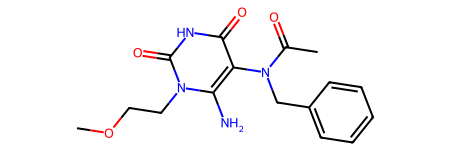

In [53]:
from rdkit import Chem
Chem.MolFromSmiles(target_smiles)

Define configuration file path for BioPKS

In [54]:
config_filepath = os.path.join('/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/BioPKS_config_file.json')

we initialize DORA-XGB, a supervised learning classifier that can help predict the feasibility of reactions catalyzed by regular, monofunctional enzymes in Biology.

In [55]:
post_pks_rxn_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat',
                                                     model_type = "spare")

initialize an object of the biopks_pipeline class

In [56]:
biopks_pipeline_object = biopks_pipeline.biopks_pipeline(
                                             pathway_sequence = pathway_sequence,
                                             target_smiles = target_smiles,
                                             target_name = target_name,
                                             feasibility_classifier = post_pks_rxn_model,
                                             pks_release_mechanism = pks_release_mechanism,
                                             config_filepath = config_filepath
                                             )


Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases


begin a combined PKS and post-PKS synthesis with BioPKS Pipeline

In [57]:
### ----- Start synthesis -----
if __name__ == "__main__":
    start_time = time.time()
    biopks_pipeline_object.run_combined_synthesis(max_designs = 4)
    biopks_pipeline_object.save_results_logs()

    print(f"Time: {time.time() - start_time: .2f} s")


Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.15384615384615385
computing module 2
   testing 600 designs
   best score is 0.14285714285714285

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']]

Closest final product is: CC=C(OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'loading: False']] is CC=C(OC)C(=O)O.

Moving onto non-PKS modifications...
Job name: gluconic_lactone_PKS0_BIO1
Job type: enzymatic network expansion forward
Job started on: 2025-12-03 17:03:47.455195
Number of generations: 1
Number of operators loaded: 3571
Number of molecules before expantion (including cofactors): 42
Number of molecules afte

In [55]:
# Run BioPKS pipeline for all molecules in the dataframe

import time
from tqdm import tqdm  # for progress bar (install with: pip install tqdm)

# Optional: Filter to only PKS-compatible molecules first
# df_to_process = EnamineAntiviralsData_top20_PKSCompatibility[
#     EnamineAntiviralsData_top20_PKSCompatibility['pksCompatible'] == True
# ].copy()

# Or process all molecules
df_to_process = EnamineAntiviralsData_top20.copy()

# Store results
results_summary = []

# Parameters (same for all runs)
pathway_sequence = ['pks','bio']
pks_release_mechanism = 'thiolysis'
config_filepath = os.path.join(
    '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BioPKS/virus/BioPKS_config_file.json'
)

# Initialize the post-PKS reaction model once (reuse for all)
post_pks_rxn_model = DORA_XGB.feasibility_classifier(
    cofactor_positioning='add_concat',
    model_type="spare"
)

# Loop through all SMILES
for idx, row in tqdm(df_to_process.iterrows(), total=len(df_to_process), desc="Processing molecules"):
    
    target_smiles = row['SMILES']
    # Create a unique target name (you can customize this)
    target_name = f"molecule_{idx+1}"
    
    print(f"\n{'-'*60}")
    print(f"Processing {idx+1}/{len(df_to_process)}: {target_name}")
    print(f"SMILES: {target_smiles}")
    print(f"{'-'*60}")
    
    try:
        start_time = time.time()
        
        # Initialize BioPKS pipeline for this molecule
        biopks_pipeline_object = biopks_pipeline.biopks_pipeline(
            pathway_sequence=pathway_sequence,
            target_smiles=target_smiles,
            target_name=target_name,
            feasibility_classifier=post_pks_rxn_model,
            pks_release_mechanism=pks_release_mechanism,
            config_filepath=config_filepath
        )
        
        # Run synthesis
        biopks_pipeline_object.run_combined_synthesis(max_designs=4)
        
        # Save results
        biopks_pipeline_object.save_results_logs()
        
        elapsed_time = time.time() - start_time
        
        # Record success
        results_summary.append({
            'index': idx,
            'SMILES': target_smiles,
            'target_name': target_name,
            'status': 'Success',
            'time_seconds': elapsed_time,
            'error': None
        })
        
        print(f" Completed in {elapsed_time:.2f} seconds")
        
    except Exception as e:
        # Record failure
        error_msg = str(e)
        results_summary.append({
            'index': idx,
            'SMILES': target_smiles,
            'target_name': target_name,
            'status': 'Failed',
            'time_seconds': None,
            'error': error_msg
        })
        
        print(f" Failed with error: {error_msg}")
        continue  # Continue to next molecule

# Create summary dataframe
results_df = pd.DataFrame(results_summary)

# Save summary
summary_path = os.path.join(outputDir, 'BioPKS_batch_processing_summary.csv')
results_df.to_csv(summary_path, index=False)

print(f"\n{'-'*60}")
print("BATCH PROCESSING COMPLETE")
print(f"{'-'*60}")
print(f"Total molecules: {len(df_to_process)}")
print(f"Successful: {(results_df['status'] == 'Success').sum()}")
print(f"Failed: {(results_df['status'] == 'Failed').sum()}")
print(f"Summary saved to: {summary_path}")
print(f"{'='*60}")

# Display summary
results_df


Processing 1/20: molecule_0
SMILES: COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3

Extender units successfully chosen for polyketide synthases

Starter units successfully chosen for polyketide synthases

Starting PKS synthesis with RetroTide
---------------------------------------------
computing module 1
   testing 120 designs
   best score is 0.14814814814814814
computing module 2
   testing 600 designs
   best score is 0.13793103448275862

Best PKS design: [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False']]

Closest final product is: CC[C@H](OC)C(=O)O

Finished PKS synthesis: closest product to the target using the top PKS design of [["AT{'substrate': 'Malonyl-CoA'}", 'loading: True'], ["AT{'substrate': 'Methoxymalonyl-CoA'}", "KR{'type': 'B1'}", 'DH{}', 'ER{}', 'loading: False']] is CC[C@H](OC)C(=O)O.

Moving onto non-PKS modifications...
Job name: molecule_0_PKS0_BIO1
Job type: enz

,index,SMILES,target_name,status,time_seconds,error
0,0,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3,molecule_0,Success,209.552551,None
1,1,COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O,molecule_1,Success,206.665011,None
2,2,COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C,molecule_2,Success,386.367615,None
3,3,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3,molecule_3,Success,207.077628,None
4,4,COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32,molecule_4,Success,212.375614,None
5,5,CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC,molecule_5,Success,207.455609,None
6,6,CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C=C3C,molecule_6,Success,207.162607,None
7,7,CC=1C=CC=C(N1)NC(=O)NC2CCCN(CC(F)(F)F)C2=O,molecule_7,Success,335.525344,None
8,8,CC1=CC=2N=CN(CC(O)CN3C(=O)NC(C)(C)C3=O)C2C=C1C,molecule_8,Success,258.441227,None
9,9,COC=1C=CC(=CN1)NC(=O)NCCC(=O)N2CC(C)OC(C)C2,molecule_9,Success,223.877909,None


Retrosynthesis Tools: IBM RXN for Chemistry

In [17]:
# Configuration Parameters
apiKey = 'apk-7a2cc4604d776559c56bf39435eb59e2ffcd2399ede3895eb750d565649d7756'

In [21]:
# IBM RXN for Chemistry - Batch Retrosynthesis Pipeline
# Process all molecules in EnamineAntiviralsData_top20 dataframe

from rxn4chemistry import RXN4ChemistryWrapper
import pandas as pd
import numpy as np
import time
import json
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

try:
    import matplotlib.pyplot as plt
    hasMatplotlib = True
except ImportError:
    hasMatplotlib = False

# ------------------------------------------------------------------
# Configuration Parameters
# ------------------------------------------------------------------
maxRoutesPerMolecule = 5
maxRetrosynthesisSteps = 6
nBeams = 10
fapThreshold = 0.6
aiModel = '12class-tokens-2021-05-14'  # use default or other model as needed

# ------------------------------------------------------------------
# Initialize RXN API Connection
# ------------------------------------------------------------------
print("Initializing IBM RXN for Chemistry API...")

try:
    rxnWrapper = RXN4ChemistryWrapper(api_key=apiKey)
    # For cloud usage this is usually not needed, but harmless:
    rxnWrapper.set_base_url('https://rxn.res.ibm.com')

    projects_response = rxnWrapper.list_all_projects()
    existingProjects = projects_response.get('projects', []) if isinstance(projects_response, dict) else []
    print("API connection successful")
    print(f"Found {len(existingProjects)} existing projects")

except Exception as e:
    print(f"API connection failed: {e}")
    print("\nPlease check:")
    print("1. API key is correctly set")
    print("2. Internet connection is active")
    print("3. Get API key from: https://rxn.res.ibm.com/rxn/user/profile")
    raise

# ------------------------------------------------------------------
# Setup Project — follow docs exactly
# ------------------------------------------------------------------
projectName = 'Enamine_Antivirals_Retrosynthesis'

print(f"\nCreating / selecting project: {projectName}")

# As in docs:
#   rxn.create_project("rxn4chemistry_tour")
#   rxn.set_project(rxn.project_id)
try:
    rxnWrapper.create_project(projectName)
    rxnWrapper.set_project(rxnWrapper.project_id)
    projectId = rxnWrapper.project_id
    print(f"Using project '{projectName}' with ID: {projectId}")
except Exception as e:
    # If project already exists or something odd happens, try to find it
    print(f"create_project raised: {e}")
    print("Trying to find an existing project with the same name...")

    projects = rxnWrapper.list_all_projects()
    projectList = projects.get('projects', []) if isinstance(projects, dict) else []

    projectId = None
    for proj in projectList:
        if proj.get('name') == projectName:
            projectId = proj.get('id') or proj.get('project_id')
            break

    if projectId is None:
        raise RuntimeError(
            f"Could not obtain a valid project id for project '{projectName}'. "
            f"Please create a project in the RXN GUI or check your subscription."
        )

    rxnWrapper.set_project(projectId)
    print(f"Using existing project '{projectName}' with ID: {projectId}")

print("Project ID set successfully\n")

# ------------------------------------------------------------------
# Function to process a single molecule
# ------------------------------------------------------------------
def processSingleMolecule(
    smiles,
    moleculeId,
    apiWrapper,
    maxResults=5,
    maxSteps=6,
    nBeams=10,
    fap=0.6,
    aiModel='12class-tokens-2021-05-14'
):
    """
    Process a single molecule through IBM RXN retrosynthesis.
    Returns: (resultDict, errorMessage)
    """
    try:
        # As in docs:
        # predict_automatic_retrosynthesis_response = rxn.predict_automatic_retrosynthesis(product=smiles)
        rawResponse = apiWrapper.predict_automatic_retrosynthesis(
            product=smiles,
            availability_pricing_threshold=0,
            available_smiles=None,
            exclude_smiles=None,
            exclude_substructures=None,
            exclude_target_molecule=False,
            fap=fap,
            max_steps=maxSteps,
            nbeams=nBeams,
            pruning_steps=2,
            ai_model=aiModel
        )

        if not isinstance(rawResponse, dict):
            return None, f"Unexpected response type for {moleculeId}: {type(rawResponse)}"

        # Doc pattern: predict_automatic_retrosynthesis_results = rxn.get_predict_automatic_retrosynthesis_results(
        #     predict_automatic_retrosynthesis_response['prediction_id']
        # )
        if 'prediction_id' not in rawResponse:
            msg = rawResponse.get('message') or rawResponse.get('status') or "No 'prediction_id' in response."
            return None, (
                f"IBM RXN did not return a prediction_id for {moleculeId}. "
                f"Message: {msg}. Raw response: {rawResponse}"
            )

        predictionId = rawResponse['prediction_id']

        # Poll for results until status == 'SUCCESS', following docs
        retries = 0
        maxRetries = 60   # 60 * 5s = 5 minutes total

        while retries < maxRetries:
            results = apiWrapper.get_predict_automatic_retrosynthesis_results(
                prediction_id=predictionId
            )

            if not isinstance(results, dict):
                return None, f"Unexpected result type for {moleculeId}: {type(results)}"

            status = results.get('status', 'UNKNOWN')

            if status == 'SUCCESS':
                routes = results.get('retrosynthetic_paths', []) or []

                routeData = []
                for route in routes[:maxResults]:
                    sequenceIds = route.get('sequenceId') or []
                    if sequenceIds is None:
                        sequenceIds = []
                    routeInfo = {
                        'confidence': route.get('confidence'),
                        'numSteps': len(sequenceIds),
                        'sequenceIds': sequenceIds,
                        'fullRoute': route
                    }
                    routeData.append(routeInfo)

                return {
                    'predictionId': predictionId,
                    'numRoutes': len(routes),
                    'routes': routeData,
                    'fullResponse': results
                }, None

            elif status in ['FAILED', 'ERROR']:
                errorMsg = results.get('message') or f"Prediction failed with status: {status}"
                return None, errorMsg

            # Still pending
            time.sleep(5)
            retries += 1

        return None, f"Timeout waiting for results after {maxRetries * 5} seconds"

    except Exception as e:
        return None, f"Exception during retrosynthesis for {moleculeId}: {e}"

# ------------------------------------------------------------------
# Function to process all molecules in batch
# ------------------------------------------------------------------
def processBatchRetrosynthesis(
    dataframe,
    apiWrapper,
    maxResults=5,
    maxSteps=6,
    nBeams=10,
    fap=0.6,
    aiModel='12class-tokens-2021-05-14'
):
    """
    Process all molecules in dataframe through IBM RXN.
    Returns: (summaryDataframe, detailedResultsDict)
    """

    resultsSummary = []
    detailedResults = {}

    print(f"\nProcessing {len(dataframe)} molecules through IBM RXN\n")

    for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Processing"):

        targetSmiles = row['SMILES']
        moleculeId = f"molecule_{idx}"

        print(f"\n[{idx+1}/{len(dataframe)}] {moleculeId}")
        print(f"SMILES: {targetSmiles}")

        startTime = time.time()

        result, error = processSingleMolecule(
            smiles=targetSmiles,
            moleculeId=moleculeId,
            apiWrapper=apiWrapper,
            maxResults=maxResults,
            maxSteps=maxSteps,
            nBeams=nBeams,
            fap=fap,
            aiModel=aiModel
        )

        elapsedTime = time.time() - startTime

        if error:
            print(f"Failed: {error}")
            resultsSummary.append({
                'index': idx,
                'moleculeId': moleculeId,
                'smiles': targetSmiles,
                'status': 'Failed',
                'numRoutes': 0,
                'topRouteConfidence': None,
                'topRouteSteps': None,
                'predictionId': None,
                'timeSeconds': elapsedTime,
                'error': error
            })

        elif result['numRoutes'] == 0:
            print("No routes found")
            resultsSummary.append({
                'index': idx,
                'moleculeId': moleculeId,
                'smiles': targetSmiles,
                'status': 'No routes found',
                'numRoutes': 0,
                'topRouteConfidence': None,
                'topRouteSteps': None,
                'predictionId': result['predictionId'],
                'timeSeconds': elapsedTime,
                'error': None
            })

        else:
            topRoute = result['routes'][0]
            print(f"Success: {result['numRoutes']} routes found")
            if topRoute['confidence'] is not None:
                print(f"Top route: {topRoute['numSteps']} steps, confidence: {topRoute['confidence']:.3f}")
            else:
                print(f"Top route: {topRoute['numSteps']} steps, confidence: None")

            resultsSummary.append({
                'index': idx,
                'moleculeId': moleculeId,
                'smiles': targetSmiles,
                'status': 'Success',
                'numRoutes': result['numRoutes'],
                'topRouteConfidence': topRoute['confidence'],
                'topRouteSteps': topRoute['numSteps'],
                'predictionId': result['predictionId'],
                'timeSeconds': elapsedTime,
                'error': None
            })

            detailedResults[moleculeId] = {
                'smiles': targetSmiles,
                'predictionId': result['predictionId'],
                'numRoutes': result['numRoutes'],
                'routes': result['routes'],
                'processingTime': elapsedTime
            }

    return pd.DataFrame(resultsSummary), detailedResults

# ------------------------------------------------------------------
# Run Batch Processing
# ------------------------------------------------------------------
print("\nStarting Batch Retrosynthesis Analysis")
print(f"Input molecules: {len(EnamineAntiviralsData_top20)}")
print(f"Max routes per molecule: {maxRoutesPerMolecule}")
print(f"Max synthesis steps: {maxRetrosynthesisSteps}")
print(f"Project ID: {rxnWrapper.project_id}\n")

batchStartTime = time.time()

summaryDf, detailedResults = processBatchRetrosynthesis(
    dataframe=EnamineAntiviralsData_top20,
    apiWrapper=rxnWrapper,
    maxResults=maxRoutesPerMolecule,
    maxSteps=maxRetrosynthesisSteps,
    nBeams=nBeams,
    fap=fapThreshold,
    aiModel=aiModel
)

totalTime = time.time() - batchStartTime

# ------------------------------------------------------------------
# Save Results
# ------------------------------------------------------------------
print("\n\nSaving Results")

rxnOutputDir = os.path.join(outputDir, 'IBM_RXN_results')
os.makedirs(rxnOutputDir, exist_ok=True)

summaryPath = os.path.join(rxnOutputDir, 'retrosynthesis_summary.csv')
summaryDf.to_csv(summaryPath, index=False)
print(f"Summary saved: {summaryPath}")

detailedPath = os.path.join(rxnOutputDir, 'detailed_results.json')
with open(detailedPath, 'w') as f:
    json.dump(detailedResults, f, indent=2)
print(f"Detailed results saved: {detailedPath}")

routesDir = os.path.join(rxnOutputDir, 'individual_routes')
os.makedirs(routesDir, exist_ok=True)

for molId, data in detailedResults.items():
    molDir = os.path.join(routesDir, molId)
    os.makedirs(molDir, exist_ok=True)

    molData = {
        'smiles': data['smiles'],
        'numRoutes': data['numRoutes'],
        'processingTime': data['processingTime'],
        'routes': data['routes']
    }

    with open(os.path.join(molDir, 'routes.json'), 'w') as f:
        json.dump(molData, f, indent=2)

print(f"Individual routes saved: {routesDir}")

# ------------------------------------------------------------------
# Generate Statistics
# ------------------------------------------------------------------
print("\n\nAnalysis Summary")

totalMolecules = len(summaryDf)
successful = (summaryDf['status'] == 'Success').sum()
noRoutes = (summaryDf['status'] == 'No routes found').sum()
failed = (summaryDf['status'] == 'Failed').sum()

print(f"Total molecules processed: {totalMolecules}")
print(f"Successful: {successful} ({100*successful/totalMolecules:.1f}%)")
print(f"No routes found: {noRoutes} ({100*noRoutes/totalMolecules:.1f}%)")
print(f"Failed: {failed} ({100*failed/totalMolecules:.1f}%)")
print(f"\nTotal processing time: {totalTime/60:.1f} minutes")
print(f"Average time per molecule: {totalTime/totalMolecules:.1f} seconds")

if successful > 0:
    successDf = summaryDf[summaryDf['status'] == 'Success']

    print(f"\nRoute Statistics (successful molecules):")
    print(f"Average routes per molecule: {successDf['numRoutes'].mean():.1f}")
    print(f"Average synthesis steps: {successDf['topRouteSteps'].mean():.1f}")
    print(f"Average confidence: {successDf['topRouteConfidence'].mean():.3f}")

    print(f"\nBest Results:")
    print(f"Highest confidence: {successDf['topRouteConfidence'].max():.3f}")
    print(f"Shortest synthesis: {successDf['topRouteSteps'].min()} steps")
    print(f"Most routes found: {successDf['numRoutes'].max()}")

# ------------------------------------------------------------------
# Display Top Molecules
# ------------------------------------------------------------------
if successful > 0:
    print("\n\nTop 5 Molecules by Confidence")

    top5 = summaryDf[summaryDf['status'] == 'Success'].nlargest(5, 'topRouteConfidence')

    for _, row in top5.iterrows():
        print(f"\n{row['moleculeId']}:")
        print(f"  SMILES: {row['smiles']}")
        print(f"  Confidence: {row['topRouteConfidence']:.3f}")
        print(f"  Steps: {row['topRouteSteps']}")
        print(f"  Total routes: {row['numRoutes']}")

    print("\n\nTop 5 Shortest Syntheses")

    shortest5 = summaryDf[summaryDf['status'] == 'Success'].nsmallest(5, 'topRouteSteps')

    for _, row in shortest5.iterrows():
        print(f"\n{row['moleculeId']}:")
        print(f"  SMILES: {row['smiles']}")
        print(f"  Steps: {row['topRouteSteps']}")
        print(f"  Confidence: {row['topRouteConfidence']:.3f}")
        print(f"  Total routes: {row['numRoutes']}")

# ------------------------------------------------------------------
# Create Visualizations
# ------------------------------------------------------------------
if hasMatplotlib and successful > 0:
    print("\n\nGenerating Visualizations")

    successDf = summaryDf[summaryDf['status'] == 'Success']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].hist(successDf['topRouteSteps'], bins=15)
    axes[0, 0].set_xlabel('Number of Synthesis Steps')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Synthesis Route Lengths')
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].hist(successDf['topRouteConfidence'], bins=15)
    axes[0, 1].set_xlabel('Confidence Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Route Confidence Scores')
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(
        successDf['numRoutes'],
        bins=range(1, int(successDf['numRoutes'].max()) + 2)
    )
    axes[1, 0].set_xlabel('Number of Routes Found')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Routes per Molecule')
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].scatter(
        successDf['topRouteSteps'],
        successDf['topRouteConfidence'],
        alpha=0.6,
        s=50
    )
    axes[1, 1].set_xlabel('Number of Steps')
    axes[1, 1].set_ylabel('Confidence Score')
    axes[1, 1].set_title('Route Confidence vs Synthesis Length')
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()

    vizPath = os.path.join(rxnOutputDir, 'analysis_visualizations.png')
    plt.savefig(vizPath, dpi=300, bbox_inches='tight')
    print(f"Visualizations saved: {vizPath}")
    plt.show()

# ------------------------------------------------------------------
# Status Breakdown
# ------------------------------------------------------------------
print("\n\nStatus Breakdown")

statusCounts = summaryDf['status'].value_counts()
for status, count in statusCounts.items():
    print(f"{status}: {count} molecules")

# ------------------------------------------------------------------
# Final Summary
# ------------------------------------------------------------------
print("\n\nProcessing Complete")
print(f"All results saved to: {rxnOutputDir}")
print("\nFiles created:")
print("  retrosynthesis_summary.csv")
print("  detailed_results.json")
print("  individual_routes/")
if hasMatplotlib and successful > 0:
    print("  analysis_visualizations.png")

print("\n")

summaryDf


Initializing IBM RXN for Chemistry API...
API connection successful
Found 0 existing projects

Creating / selecting project: Enamine_Antivirals_Retrosynthesis
Using project 'Enamine_Antivirals_Retrosynthesis' with ID: None
Project ID set successfully


Starting Batch Retrosynthesis Analysis
Input molecules: 20
Max routes per molecule: 5
Max synthesis steps: 6
Project ID: None


Processing 20 molecules through IBM RXN


[1/20] molecule_0
SMILES: COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3
Failed: Exception during retrosynthesis for molecule_0: Project identifier has to be set first.

[2/20] molecule_1
SMILES: COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O
Failed: Exception during retrosynthesis for molecule_1: Project identifier has to be set first.

[3/20] molecule_2
SMILES: COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C
Failed: Exception during retrosynthesis for molecule_2: Project identifier has to be set first.

[4/20] molecule_3
SMILES: COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3


,index,moleculeId,smiles,status,numRoutes,topRouteConfidence,topRouteSteps,predictionId,timeSeconds,error
0,0,molecule_0,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)N(C)CC=3C=CC=CC3,Failed,0,None,None,None,0.000091,Exception during retrosynthesis for molecule_0...
1,1,molecule_1,COCCN1C(=O)NC(=O)C(=C1N)N(CC=2C=CC=CC2)C(C)=O,Failed,0,None,None,None,0.000042,Exception during retrosynthesis for molecule_1...
2,2,molecule_2,COCCN1C=C(C=CC1=O)NC(=O)C2C(C=C(C)C)C2(C)C,Failed,0,None,None,None,0.000034,Exception during retrosynthesis for molecule_2...
3,3,molecule_3,COCCN1C(=NC2=C1C(=O)NC(=O)N2C)NN=CC=3C=CC=CC3,Failed,0,None,None,None,0.000032,Exception during retrosynthesis for molecule_3...
4,4,molecule_4,COC=1C=CC(OC)=C(C1)C(O)CN2C(C)=NC=3C=CC=CC32,Failed,0,None,None,None,0.000034,Exception during retrosynthesis for molecule_4...
5,5,molecule_5,CCC=1C=C(CC)N(N1)C2=NC3=C(C(=O)NC(=O)N3C)N2CCOC,Failed,0,None,None,None,0.000033,Exception during retrosynthesis for molecule_5...
6,6,molecule_6,CCOCCN1C(=NC2=C1C(=O)NC(=O)N2C)N3N=C(C)C=C3C,Failed,0,None,None,None,0.000032,Exception during retrosynthesis for molecule_6...
7,7,molecule_7,CC=1C=CC=C(N1)NC(=O)NC2CCCN(CC(F)(F)F)C2=O,Failed,0,None,None,None,0.000031,Exception during retrosynthesis for molecule_7...
8,8,molecule_8,CC1=CC=2N=CN(CC(O)CN3C(=O)NC(C)(C)C3=O)C2C=C1C,Failed,0,None,None,None,0.000034,Exception during retrosynthesis for molecule_8...
9,9,molecule_9,COC=1C=CC(=CN1)NC(=O)NCCC(=O)N2CC(C)OC(C)C2,Failed,0,None,None,None,0.000030,Exception during retrosynthesis for molecule_9...
